<a href="https://colab.research.google.com/github/laboratoriodecodigos/Colab-Python/blob/main/cariotipado_de_cromosomas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aliabedimadiseh/chromosome-image-dataset-karyotype")

print("Path to dataset files:", path)

100%|██████████| 990M/990M [00:58<00:00, 17.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/aliabedimadiseh/chromosome-image-dataset-karyotype/versions/4


In [ ]:
!pip install -U ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 56.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.5/96.5 kB 8.6 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

model = YOLO("yolo26s-seg.pt")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [ ]:
import os
os.listdir(path+'/Data')

['weight',
 'Readme.txt',
 'diff_image.txt',
 'single_chromosomes_object',
 'train.txt',
 'structural_abnormalities.csv',
 'test.txt',
 '24_chromosomes_object',
 'number_abnormalities.csv',
 'normal.csv']

In [ ]:
import os
import shutil
from pathlib import Path

# Definir rutas origen y destino
data_origin = Path(path) / 'Data'
dest_dataset = Path('/content/datasets/chromosome')

# Crear estructura de carpetas estándar para YOLO
for split in ['train', 'val']:
    (dest_dataset / 'images' / split).mkdir(parents=True, exist_ok=True)
    (dest_dataset / 'labels' / split).mkdir(parents=True, exist_ok=True)

print("Estructura de directorios YOLO creada en:", dest_dataset)


Estructura de directorios YOLO creada en: /content/datasets/chromosome


In [ ]:
# Script para mapear y copiar imágenes y etiquetas del dataset original
# Vamos a inspeccionar los primeros elementos de train.txt para entender cómo están listadas las imágenes
with open(data_origin / 'train.txt', 'r') as f:
    train_lines = [line.strip() for line in f.readlines()]

print("Ejemplo de rutas en train.txt:")
for line in train_lines[:5]:
    print(line)


Ejemplo de rutas en train.txt:
103064
103071
103072
103081
103082


In [ ]:
# Busquemos dónde se encuentran las imágenes y etiquetas usando el ID de ejemplo
ejemplo_id = '103064'
print("Buscando archivos que contengan el ID de ejemplo...")
for root, dirs, files in os.walk(data_origin):
    for file in files:
        if ejemplo_id in file:
            print(f"Encontrado: {os.path.join(root, file)}")

Buscando archivos que contengan el ID de ejemplo...
Encontrado: /root/.cache/kagglehub/datasets/aliabedimadiseh/chromosome-image-dataset-karyotype/versions/4/Data/single_chromosomes_object/JEPG/103064.jpg
Encontrado: /root/.cache/kagglehub/datasets/aliabedimadiseh/chromosome-image-dataset-karyotype/versions/4/Data/single_chromosomes_object/anntations/103064.xml
Encontrado: /root/.cache/kagglehub/datasets/aliabedimadiseh/chromosome-image-dataset-karyotype/versions/4/Data/24_chromosomes_object/annotations/103064.xml
Encontrado: /root/.cache/kagglehub/datasets/aliabedimadiseh/chromosome-image-dataset-karyotype/versions/4/Data/24_chromosomes_object/JEPG/103064.jpg


In [ ]:
# Script para mapear y copiar imágenes y etiquetas del dataset original a YOLO
import glob

def copiar_datos(split_name, txt_file_name):
    txt_path = data_origin / txt_file_name
    if not txt_path.exists():
        print(f"El archivo {txt_file_name} no existe.")
        return

    with open(txt_path, 'r') as f:
        ids = {line.strip() for line in f.readlines() if line.strip()}

    print(f"Procesando {len(ids)} archivos para el split: {split_name}...")

    copiados = 0
    for root, dirs, files in os.walk(data_origin):
        for file in files:
            file_path = Path(root) / file
            file_stem = file_path.stem
            if file_stem in ids:
                if file_path.suffix.lower() in ['.png', '.jpg', '.jpeg']:
                    shutil.copy(file_path, dest_dataset / 'images' / split_name)
                    copiados += 1
                elif file_path.suffix.lower() == '.txt' and file != txt_file_name:
                    shutil.copy(file_path, dest_dataset / 'labels' / split_name)

    print(f"Copiadas {copiados} imágenes para {split_name}.")

copiar_datos('train', 'train.txt')
copiar_datos('val', 'test.txt')

Procesando 3750 archivos para el split: train...
Copiadas 4463 imágenes para train.
Procesando 1250 archivos para el split: val...
Copiadas 2366 imágenes para val.


In [ ]:
# Busquemos dónde se encuentran las imágenes y etiquetas usando el ID de ejemplo '103064'
ejemplo_id = '103064'

print("Buscando archivos que contengan el ID de ejemplo...")
for root, dirs, files in os.walk(data_origin):
    for file in files:
        if ejemplo_id in file:
            print(f"Encontrado: {os.path.join(root, file)}")

Buscando archivos que contengan el ID de ejemplo...
Encontrado: /root/.cache/kagglehub/datasets/aliabedimadiseh/chromosome-image-dataset-karyotype/versions/4/Data/single_chromosomes_object/JEPG/103064.jpg
Encontrado: /root/.cache/kagglehub/datasets/aliabedimadiseh/chromosome-image-dataset-karyotype/versions/4/Data/single_chromosomes_object/anntations/103064.xml
Encontrado: /root/.cache/kagglehub/datasets/aliabedimadiseh/chromosome-image-dataset-karyotype/versions/4/Data/24_chromosomes_object/annotations/103064.xml
Encontrado: /root/.cache/kagglehub/datasets/aliabedimadiseh/chromosome-image-dataset-karyotype/versions/4/Data/24_chromosomes_object/JEPG/103064.jpg


In [ ]:
# Una vez ubicado el patrón de archivos, procederemos a copiar todas las imágenes y etiquetas de entrenamiento y validación
import glob

def copiar_datos(split_name, txt_file_name):
    txt_path = data_origin / txt_file_name
    if not txt_path.exists():
        print(f"El archivo {txt_file_name} no existe.")
        return

    with open(txt_path, 'r') as f:
        ids = [line.strip() for line in f.readlines() if line.strip()]

    print(f"Procesando {len(ids)} archivos para el split: {split_name}...")

    # Buscaremos todos los archivos .png / .jpg y sus respectivos .txt de etiquetas en el origen
    copiados = 0
    for root, dirs, files in os.walk(data_origin):
        for file in files:
            file_path = Path(root) / file
            # Si el archivo empieza con alguno de nuestros IDs mapeados
            file_stem = file_path.stem
            if file_stem in ids:
                if file_path.suffix.lower() in ['.png', '.jpg', '.jpeg']:
                    shutil.copy(file_path, dest_dataset / 'images' / split_name)
                    copiados += 1
                elif file_path.suffix.lower() == '.txt' and file != txt_file_name:
                    shutil.copy(file_path, dest_dataset / 'labels' / split_name)

    print(f"Copiadas {copiados} imágenes para {split_name}.")

# Copiamos para train y val
copiar_datos('train', 'train.txt')
copiar_datos('val', 'test.txt')

Procesando 3750 archivos para el split: train...
Copiadas 4463 imágenes para train.
Procesando 1250 archivos para el split: val...
Copiadas 2366 imágenes para val.


In [ ]:
import xml.etree.ElementTree as ET
from pathlib import Path
import os

def xml_to_yolo_bbox(xml_path, classes_list):
    """Convierte un archivo XML Pascal VOC a formato de etiquetas YOLO."""
    try:
        tree = ET.parse(xml_path)
    except Exception as e:
        return []
    root = tree.getroot()

    size = root.find('size')
    if size is None:
        return []
    w = int(size.find('width').text)
    h = int(size.find('height').text)

    if w == 0 or h == 0:
        return []

    yolo_lines = []
    for obj in root.iter('object'):
        cls_name = obj.find('name').text
        if cls_name not in classes_list:
            classes_list.append(cls_name)
        cls_id = classes_list.index(cls_name)

        xmlbox = obj.find('bndbox')
        xmin = float(xmlbox.find('xmin').text)
        xmax = float(xmlbox.find('xmax').text)
        ymin = float(xmlbox.find('ymin').text)
        ymax = float(xmlbox.find('ymax').text)

        # Convertir a coordenadas normalizadas del centro de la caja
        x_center = (xmin + xmax) / (2.0 * w)
        y_center = (ymin + ymax) / (2.0 * h)
        bbox_width = (xmax - xmin) / w
        bbox_height = (ymax - ymin) / h

        yolo_lines.append(f"{cls_id} {x_center:.6f} {y_center:.6f} {bbox_width:.6f} {bbox_height:.6f}")
    return yolo_lines

In [ ]:
classes = []

def procesar_etiquetas_xml(split_name, txt_file_name):
    txt_path = data_origin / txt_file_name
    with open(txt_path, 'r') as f:
        ids = {line.strip() for line in f.readlines() if line.strip()}

    labels_dir = dest_dataset / 'labels' / split_name
    labels_dir.mkdir(parents=True, exist_ok=True)

    convertidos = 0
    for root, dirs, files in os.walk(data_origin):
        for file in files:
            file_path = Path(root) / file
            if file_path.suffix.lower() == '.xml' and file_path.stem in ids:
                yolo_lines = xml_to_yolo_bbox(file_path, classes)
                if yolo_lines:
                    out_txt_path = labels_dir / f"{file_path.stem}.txt"
                    with open(out_txt_path, 'w') as out_f:
                        out_f.write('\n'.join(yolo_lines))
                    convertidos += 1

    print(f"Convertidos {convertidos} archivos XML para {split_name}.")

procesar_etiquetas_xml('train', 'train.txt')
procesar_etiquetas_xml('val', 'test.txt')
print("Clases detectadas:", classes)

Convertidos 4463 archivos XML para train.
Convertidos 2366 archivos XML para val.
Clases detectadas: ['chromosomes', 'A1', 'A2', 'A3', 'B4', 'B5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'D13', 'D14', 'D15', 'E16', 'E17', 'E18', 'F19', 'F20', 'G21', 'G22', 'X', 'Y']


In [ ]:
yaml_content = f"""path: {dest_dataset}
train: images/train
val: images/val

names:\n"""
for i, cls in enumerate(classes):
    yaml_content += f"  {i}: {cls}\n"

yaml_path = dest_dataset / 'dataset.yaml'
with open(yaml_path, 'w') as f:
    f.write(yaml_content)

print(f"Archivo dataset.yaml generado en: {yaml_path}")
print(yaml_content)

Archivo dataset.yaml generado en: /content/datasets/chromosome/dataset.yaml
path: /content/datasets/chromosome
train: images/train
val: images/val

names:
  0: chromosomes
  1: A1
  2: A2
  3: A3
  4: B4
  5: B5
  6: C6
  7: C7
  8: C8
  9: C9
  10: C10
  11: C11
  12: C12
  13: D13
  14: D14
  15: D15
  16: E16
  17: E17
  18: E18
  19: F19
  20: F20
  21: G21
  22: G22
  23: X
  24: Y



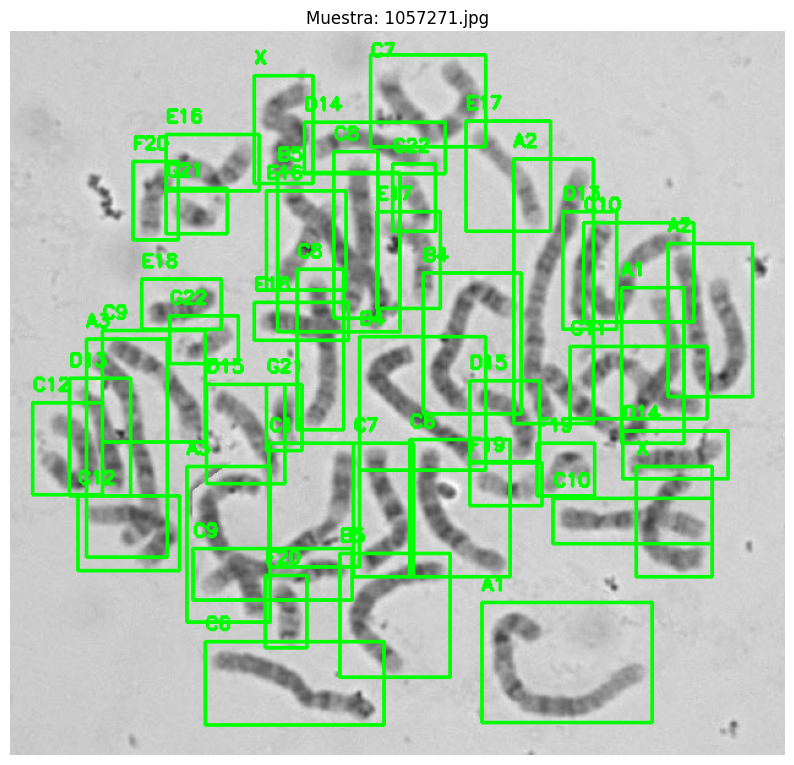

In [ ]:
import cv2
import matplotlib.pyplot as plt
import random
from pathlib import Path

# Rutas de las imágenes y etiquetas procesadas
images_dir = dest_dataset / 'images' / 'train'
labels_dir = dest_dataset / 'labels' / 'train'

# Seleccionar una imagen aleatoria que tenga etiquetas en formato txt
lista_imagenes = list(images_dir.glob('*.jpg'))
imagen_path = random.choice(lista_imagenes)
etiqueta_path = labels_dir / f"{imagen_path.stem}.txt"

# Cargar imagen
img = cv2.imread(str(imagen_path))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w, _ = img.shape

# Leer y dibujar las cajas de YOLO
if etiqueta_path.exists():
    with open(etiqueta_path, 'r') as f:
        lineas = f.readlines()

    for linea in lineas:
        valores = linea.strip().split()
        if len(valores) == 5:
            cls_id, x_center, y_center, bbox_w, bbox_h = map(float, valores)

            # Convertir coordenadas de YOLO a píxeles absolutos
            x1 = int((x_center - bbox_w / 2) * w)
            y1 = int((y_center - bbox_h / 2) * h)
            x2 = int((x_center + bbox_w / 2) * w)
            y2 = int((y_center + bbox_h / 2) * h)

            cls_name = classes[int(cls_id)] if int(cls_id) < len(classes) else str(int(cls_id))

            # Dibujar rectángulo y texto de etiqueta
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(img, cls_name, (x1, max(y1 - 10, 20)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

# Mostrar la imagen con matplotlib
plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.title(f"Muestra: {imagen_path.name}")
plt.axis('off')
plt.show()

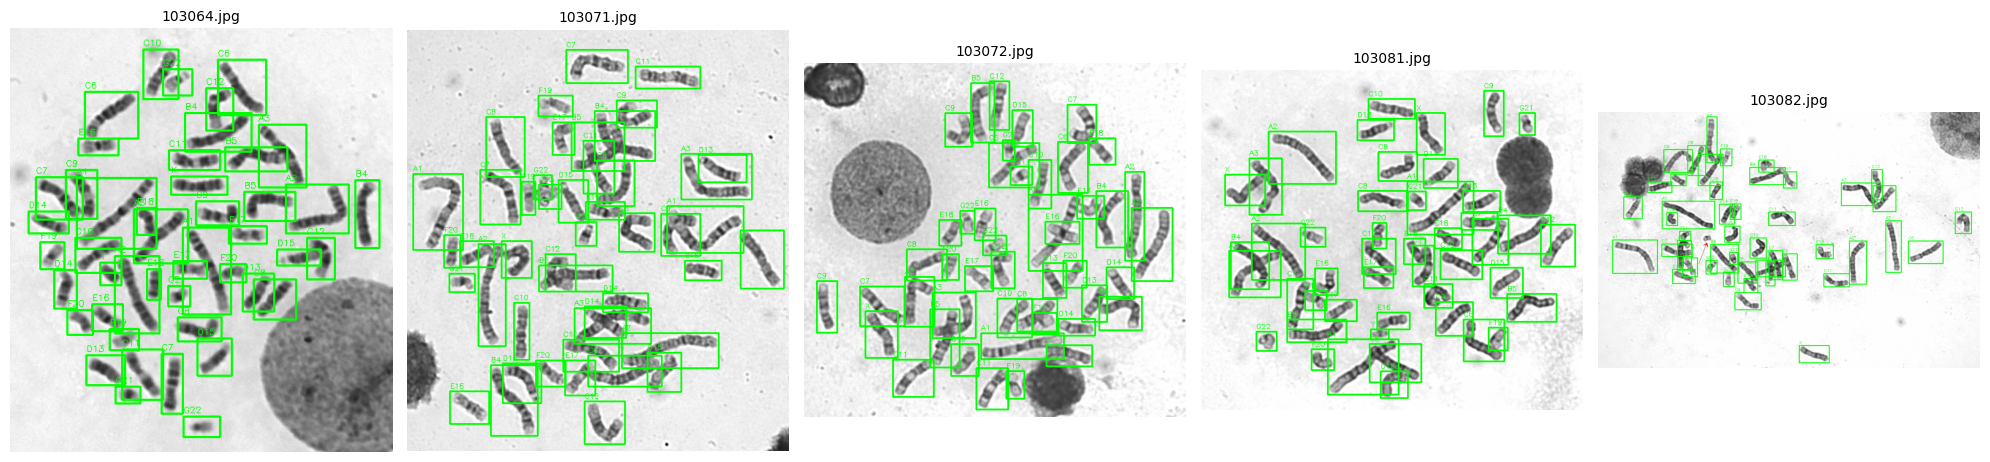

In [ ]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

# Obtener las primeras 5 imágenes del conjunto de entrenamiento
lista_imagenes_5 = sorted(list(images_dir.glob('*.jpg')))[:5]

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for idx, img_path in enumerate(lista_imagenes_5):
    # Cargar y preparar imagen
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape

    etiqueta_path = labels_dir / f"{img_path.stem}.txt"

    if etiqueta_path.exists():
        with open(etiqueta_path, 'r') as f:
            lineas = f.readlines()

        for linea in lineas:
            valores = linea.strip().split()
            if len(valores) == 5:
                cls_id, x_center, y_center, bbox_w, bbox_h = map(float, valores)

                # Convertir coordenadas YOLO normalizadas a coordenadas de píxeles
                x1 = int((x_center - bbox_w / 2) * w)
                y1 = int((y_center - bbox_h / 2) * h)
                x2 = int((x_center + bbox_w / 2) * w)
                y2 = int((y_center + bbox_h / 2) * h)

                cls_name = classes[int(cls_id)] if int(cls_id) < len(classes) else str(int(cls_id))

                # Dibujar caja y clase
                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(img, cls_name, (x1, max(y1 - 5, 15)), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1)

    axes[idx].imshow(img)
    axes[idx].set_title(img_path.name, fontsize=10)
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from ultralytics import YOLO

model_detection = YOLO('yolov8s.pt')

# Iniciar el entrenamiento con los datos preparados
results = model_detection.train(
    data=str(yaml_path),
    epochs=25,          # Número inicial de épocas (puedes aumentarlo más adelante)
    imgsz=640,          # Tamaño de imagen de entrada recomendado
    batch=16,           # Tamaño del lote
    device=0,           # Usar GPU (0) si está disponible
    project='chromosome_detection',
    name='yolov8s_run'
)

Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets/chromosome/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_run, nbs=64, nms=None, opset=None, opti

### Visualización de las Curvas de Entrenamiento (Pérdida y Precisión)

Cargamos la imagen `results.png` autogenerada por YOLO durante el entrenamiento para analizar el comportamiento de las pérdidas y las métricas de precisión.

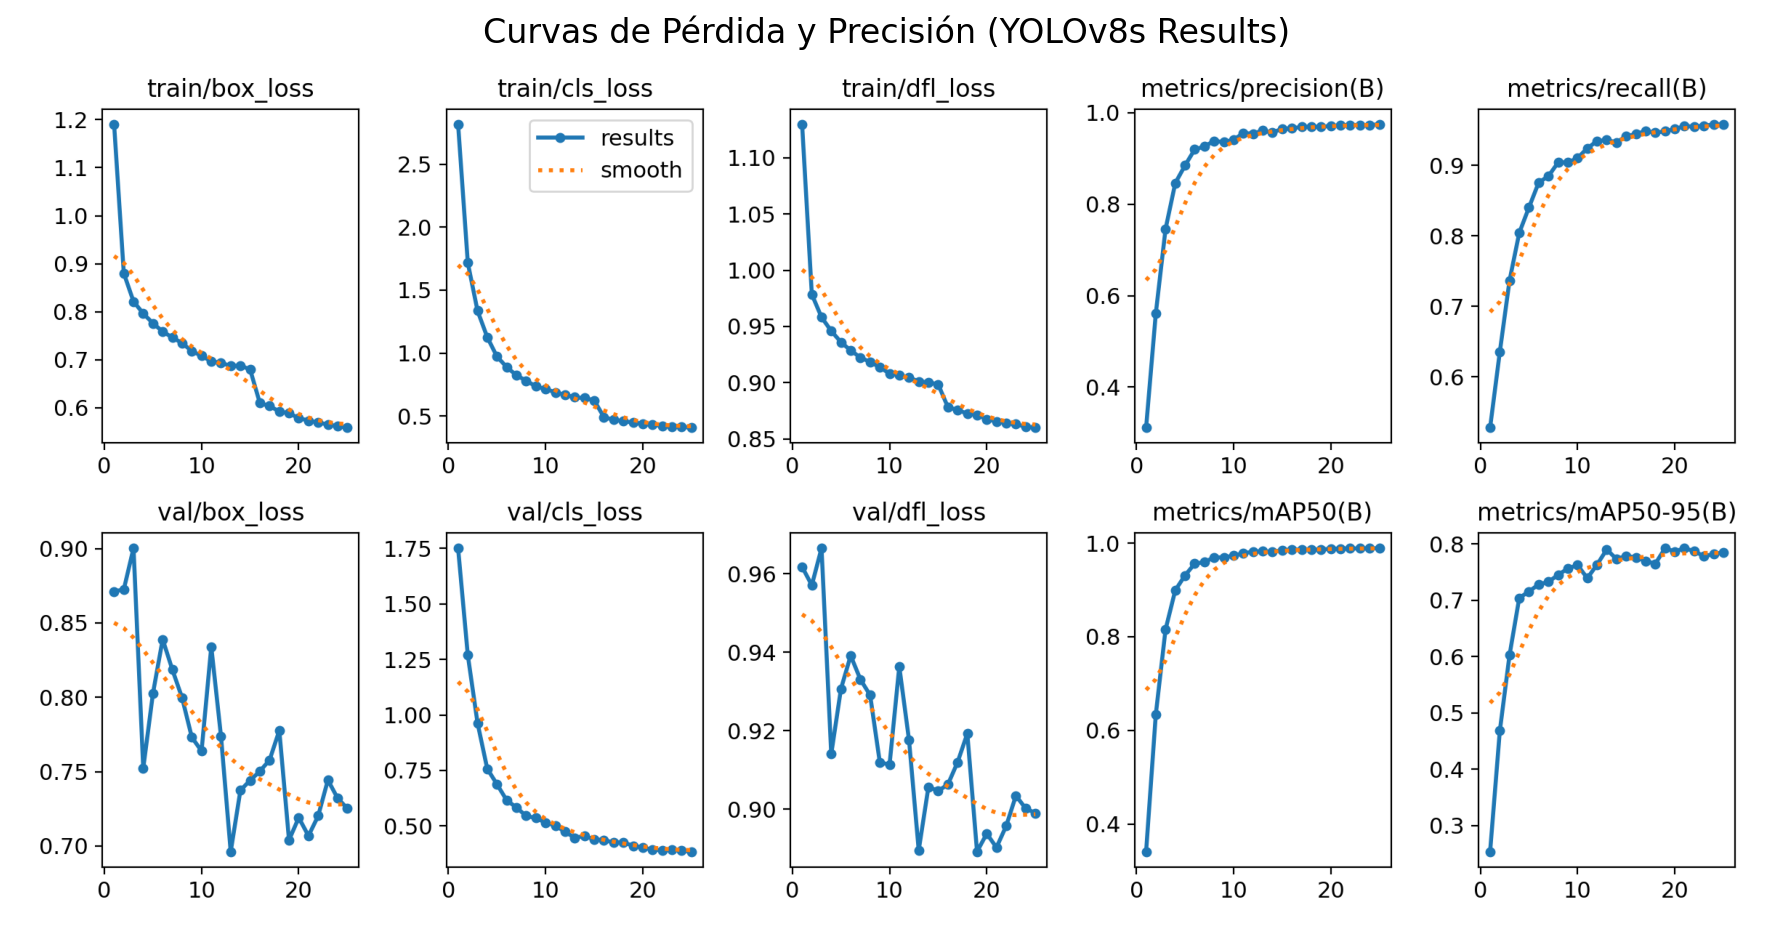

In [ ]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

# Ruta del archivo de resultados de la ejecución
results_png_path = Path('/content/runs/detect/chromosome_detection/yolov8s_run/results.png')

if results_png_path.exists():
    # Leer e invertir canales de color para mostrar con Matplotlib
    img_results = cv2.imread(str(results_png_path))
    img_results = cv2.cvtColor(img_results, cv2.COLOR_BGR2RGB)

    # Graficar la imagen de resultados en alta resolución
    plt.figure(figsize=(15, 12), dpi=150)
    plt.imshow(img_results)
    plt.axis('off')
    plt.title('Curvas de Pérdida y Precisión (YOLOv8s Results)', fontsize=16)
    plt.show()
else:
    print(f"No se encontró el archivo de resultados en: {results_png_path}")

### Evaluación Completa del Modelo en el Conjunto de Validación

Cargamos el mejor modelo guardado (`best.pt`) y lo evaluamos sobre todo el conjunto de validación para generar el reporte de métricas oficial por clase.

In [ ]:
from ultralytics import YOLO

# Ruta a los mejores pesos obtenidos durante el entrenamiento
best_weights_path = '/content/runs/detect/chromosome_detection/yolov8s_run/weights/best.pt'

# Cargar el modelo entrenado
model_eval = YOLO(best_weights_path)

# Ejecutar la validación completa
metrics_summary = model_eval.val(split='val')

# Imprimir algunas métricas generales clave
print("\n--- RESUMEN DE MÉTRICAS GENERALES ---")
print(f"mAP50: {metrics_summary.box.map50:.4f}")
print(f"mAP50-95: {metrics_summary.box.map:.4f}")
print(f"Precision Media: {metrics_summary.box.mp:.4f}")
print(f"Recall Medio: {metrics_summary.box.mr:.4f}")

Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 11,135,259 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2365.1±731.7 MB/s, size: 108.1 KB)
val: Scanning /content/datasets/chromosome/labels/val.cache... 1250 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1250/1250 308.4Mit/s 0.0s
val: /content/datasets/chromosome/images/val/1050861.jpg: corrupt JPEG restored and saved
val: /content/datasets/chromosome/images/val/1050922.jpg: corrupt JPEG restored and saved
val: /content/datasets/chromosome/images/val/1051072.jpg: corrupt JPEG restored and saved
val: /content/datasets/chromosome/images/val/1051162.jpg: corrupt JPEG restored and saved
val: /content/datasets/chromosome/images/val/1051851.jpg: corrupt JPEG restored and saved
val: /content/datasets/chromosome/images/val/1052052.jpg: corrupt JPEG restored and saved
val: /content/datasets/chromosome/images/val/1052751.jpg: corru

### Inferencia en Imágenes Aleatorias del Set de Prueba

Seleccionamos de forma aleatoria varias imágenes del set de validación, aplicamos el modelo entrenado (`best.pt`) para detectar los cromosomas y graficamos los resultados visuales.

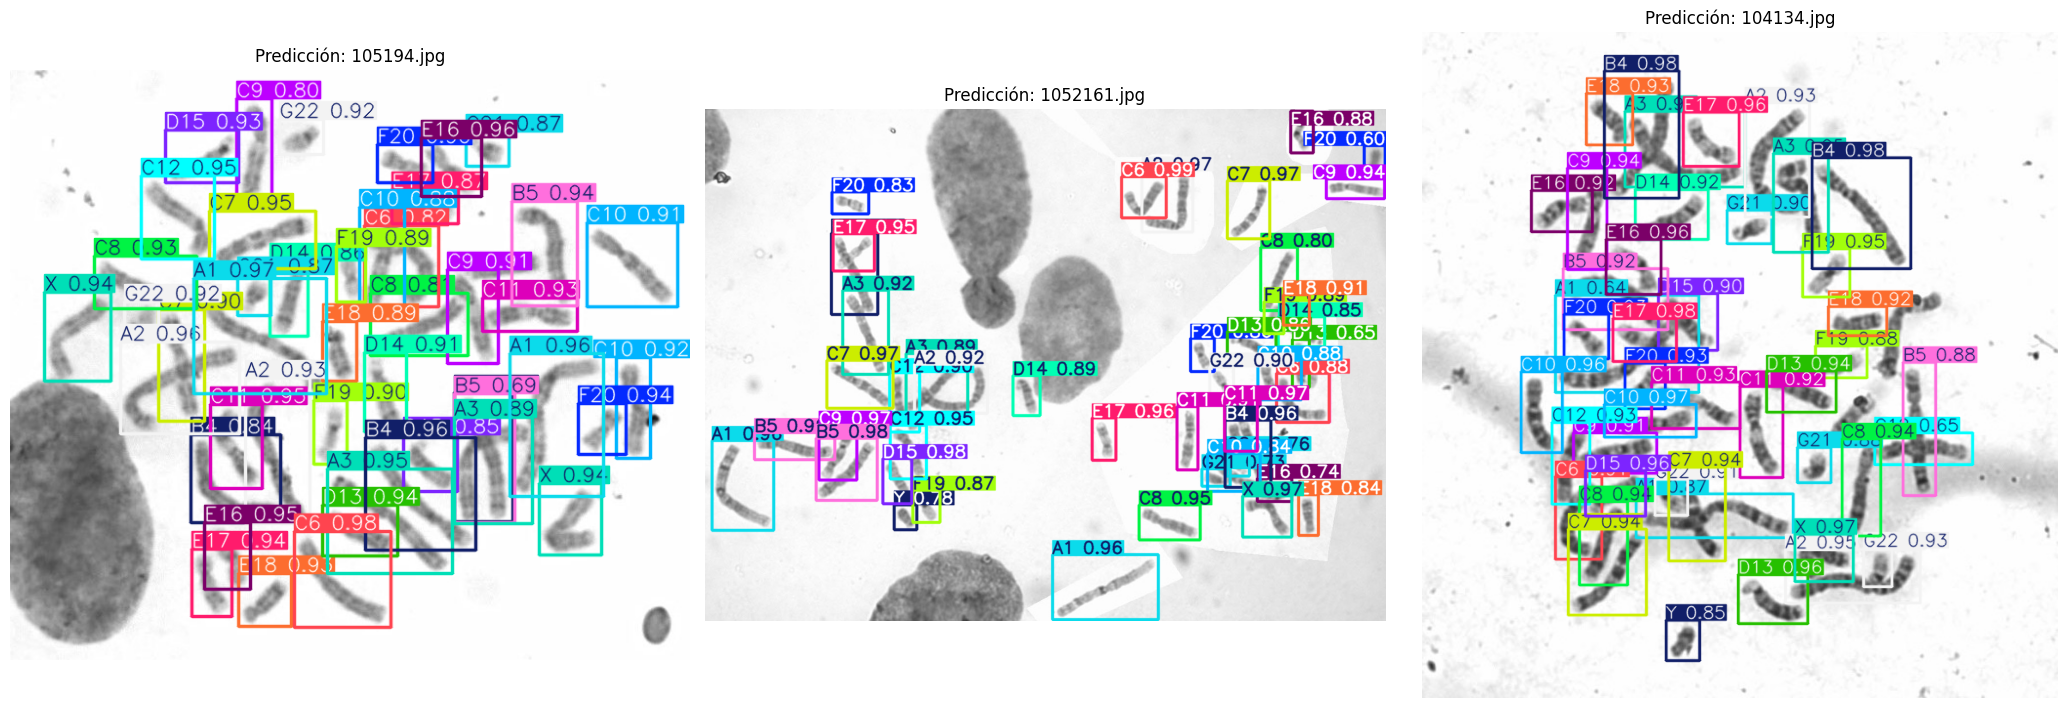

In [ ]:
import cv2
import random
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

# Ruta a las imágenes de validación
val_images_dir = Path('/content/datasets/chromosome/images/val')
lista_val_images = list(val_images_dir.glob('*.jpg'))

# Seleccionar 3 imágenes aleatorias
imágenes_muestra = random.sample(lista_val_images, 3)

# Cargar el modelo entrenado
best_weights_path = '/content/runs/detect/chromosome_detection/yolov8s_run/weights/best.pt'
model_inference = YOLO(best_weights_path)

# Configurar la visualización
fig, axes = plt.subplots(1, 3, figsize=(21, 7))

for idx, img_path in enumerate(imágenes_muestra):
    # Ejecutar inferencia
    results = model_inference.predict(source=str(img_path), conf=0.5, save=False, verbose=False)

    # Obtener la imagen con las predicciones dibujadas por YOLO
    # plot() devuelve un array BGR, lo convertimos a RGB para matplotlib
    annotated_frame = results[0].plot()
    annotated_frame = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)

    axes[idx].imshow(annotated_frame)
    axes[idx].set_title(f"Predicción: {img_path.name}", fontsize=12)
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

### Inferencia en Video con Visualización Explícita

A continuación, crearemos un pipeline para procesar un archivo de video. Como el dataset original está compuesto principalmente por imágenes de cromosomas en metafase, simularemos o utilizaremos un video para visualizar cómo el modelo detecta y clasifica dinámicamente cada cromosoma en tiempo real.

In [ ]:
import cv2
import numpy as np
from ultralytics import YOLO
from pathlib import Path

# 1. Cargar el modelo entrenado
best_weights_path = '/content/runs/detect/chromosome_detection/yolov8s_run/weights/best.pt'
model_video = YOLO(best_weights_path)

# 2. Generar un video sintético/demo a partir de imágenes de validación en caso de no contar con un archivo de video real
# Esto simulará un paneo o movimiento sobre una metafase de cromosomas para verificar la detección en video.
val_images_dir = Path('/content/datasets/chromosome/images/val')
lista_val_images = sorted(list(val_images_dir.glob('*.jpg')))

video_input_path = '/content/entrada_cromosomas.mp4'
video_output_path = '/content/resultado_cromosomas.mp4'

# Configuraciones del video de prueba (10 segundos a 3 frames por segundo)
fps = 3
width, height = 640, 640
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
video_writer = cv2.VideoWriter(video_input_path, fourcc, fps, (width, height))

print("Generando video de prueba a partir de imágenes del dataset...")
for img_path in lista_val_images[:30]: # Usamos 30 imágenes consecutivas
    img = cv2.imread(str(img_path))
    img_resized = cv2.resize(img, (width, height))
    video_writer.write(img_resized)
video_writer.release()
print(f"Video de entrada de prueba guardado en: {video_input_path}")

Generando video de prueba a partir de imágenes del dataset...
Video de entrada de prueba guardado en: /content/entrada_cromosomas.mp4


In [ ]:
# 3. Procesar el video frame por frame con YOLO y guardar el resultado anotado de manera explícita
cap = cv2.VideoCapture(video_input_path)

# Configuraciones para guardar el video resultante
output_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
output_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
output_fps = int(cap.get(cv2.CAP_PROP_FPS))

# Usamos el codec 'mp4v' para asegurar compatibilidad de visualización
out_writer = cv2.VideoWriter(video_output_path, cv2.VideoWriter_fourcc(*'mp4v'), output_fps, (output_width, output_height))

frame_count = 0
print("Iniciando el procesamiento del video con el modelo de cromosomas...")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Ejecutar inferencia en el frame actual
    results = model_video.predict(source=frame, conf=0.30, verbose=False)

    # Obtener el frame anotado por YOLO (con cajas gruesas y etiquetas explícitas)
    annotated_frame = results[0].plot(line_width=3, font_size=10, labels=True, boxes=True)

    # Escribir el frame en el archivo de salida
    out_writer.write(annotated_frame)

    frame_count += 1
    if frame_count % 10 == 0:
        print(f"Procesados {frame_count} frames...")

cap.release()
out_writer.release()
print(f"¡Procesamiento completo! Video resultante guardado en: {video_output_path}")

Iniciando el procesamiento del video con el modelo de cromosomas...
Procesados 10 frames...
Procesados 20 frames...
Procesados 30 frames...
¡Procesamiento completo! Video resultante guardado en: /content/resultado_cromosomas.mp4


### Mostrar el Video Resultante en Colab

Utilizaremos una herramienta de codificación con `ffmpeg` para convertir el video procesado a un formato altamente compatible con navegadores web (`H.264`), permitiendo reproducirlo directamente aquí.

In [ ]:
import os
from IPython.display import HTML
from base64 import b64encode

# Convertir el video procesado a H.264 para reproducción en HTML5 en Colab
compressed_video_path = '/content/resultado_cromosomas_h264.mp4'
os.system(f"ffmpeg -y -i {video_output_path} -vcodec libx264 {compressed_video_path} -loglevel quiet")

# Mostrar el reproductor de video en el cuaderno
with open(compressed_video_path, "rb") as f:
    video_encoded = b64encode(f.read()).decode('utf-8')

video_html = f"""
<video width="640" height="480" controls>
      <source src="data:video/mp4;base64,{video_encoded}" type="video/mp4">
</video>
"""

display(HTML(video_html))

In [ ]:
from google.colab import files

# Ruta a los mejores pesos obtenidos durante el entrenamiento
best_model_path = '/content/runs/detect/chromosome_detection/yolov8s_run/weights/best.pt'

print("Iniciando la descarga del mejor modelo entrenado (best.pt)...\
      El proceso puede tardar unos momentos según tu conexión.")
try:
    files.download(best_model_path)
except Exception as e:
    print(f"Ocurrió un error al descargar el archivo: {e}")

Iniciando la descarga del mejor modelo entrenado (best.pt)... El proceso puede tardar unos momentos según tu conexión.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Visualización del Análisis del Dataset y Matriz de Confusión

Vamos a graficar la distribución de frecuencias de cada tipo de cromosoma en nuestro dataset de entrenamiento para entender la composición de las clases. Además, cargaremos la matriz de confusión autogenerada por YOLOv8 durante la validación para observar posibles confusiones entre cromosomas homólogos.

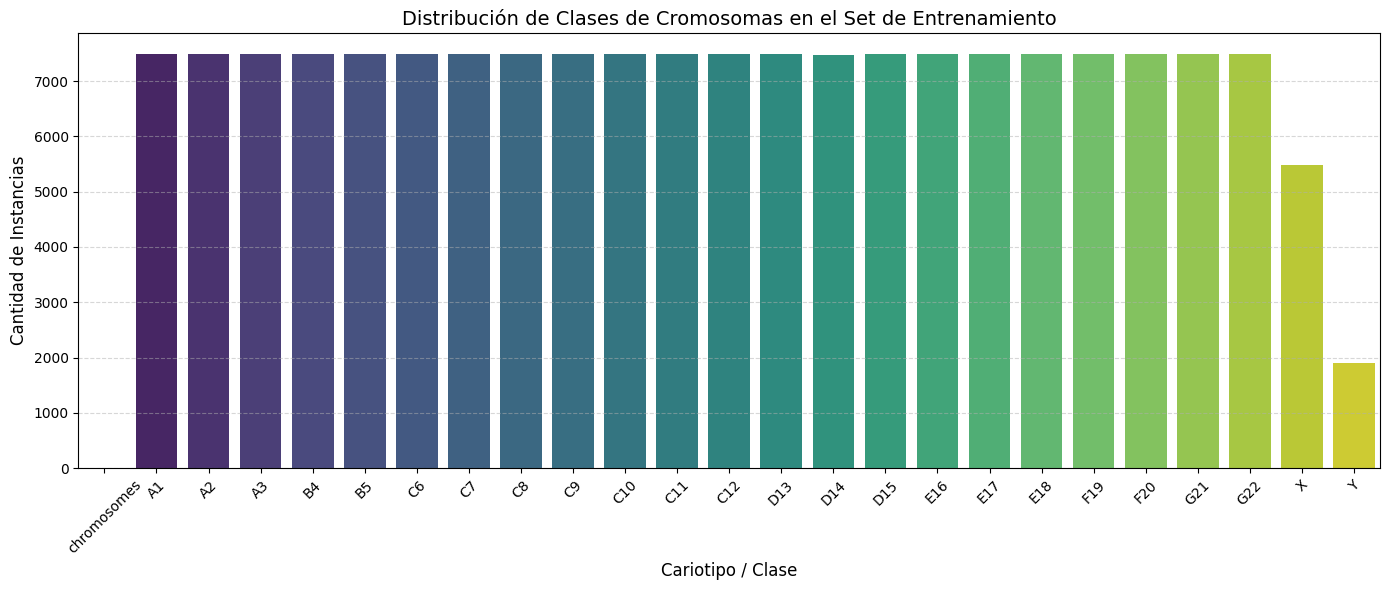

In [ ]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

# 1. Contar la distribución de etiquetas en el conjunto de entrenamiento
train_labels_dir = Path('/content/datasets/chromosome/labels/train')
class_counts = {i: 0 for i in range(len(classes))}

for label_file in train_labels_dir.glob('*.txt'):
    with open(label_file, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if parts:
                cls_id = int(parts[0])
                if cls_id in class_counts:
                    class_counts[cls_id] += 1

# Mapear IDs de clase a sus nombres reales
class_names = [classes[i] for i in range(len(classes))]
counts = [class_counts[i] for i in range(len(classes))]

# Graficar la distribución de clases
plt.figure(figsize=(14, 6))
sns.barplot(x=class_names, y=counts, palette='viridis', hue=class_names, legend=False)
plt.title('Distribución de Clases de Cromosomas en el Set de Entrenamiento', fontsize=14)
plt.xlabel('Cariotipo / Clase', fontsize=12)
plt.ylabel('Cantidad de Instancias', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

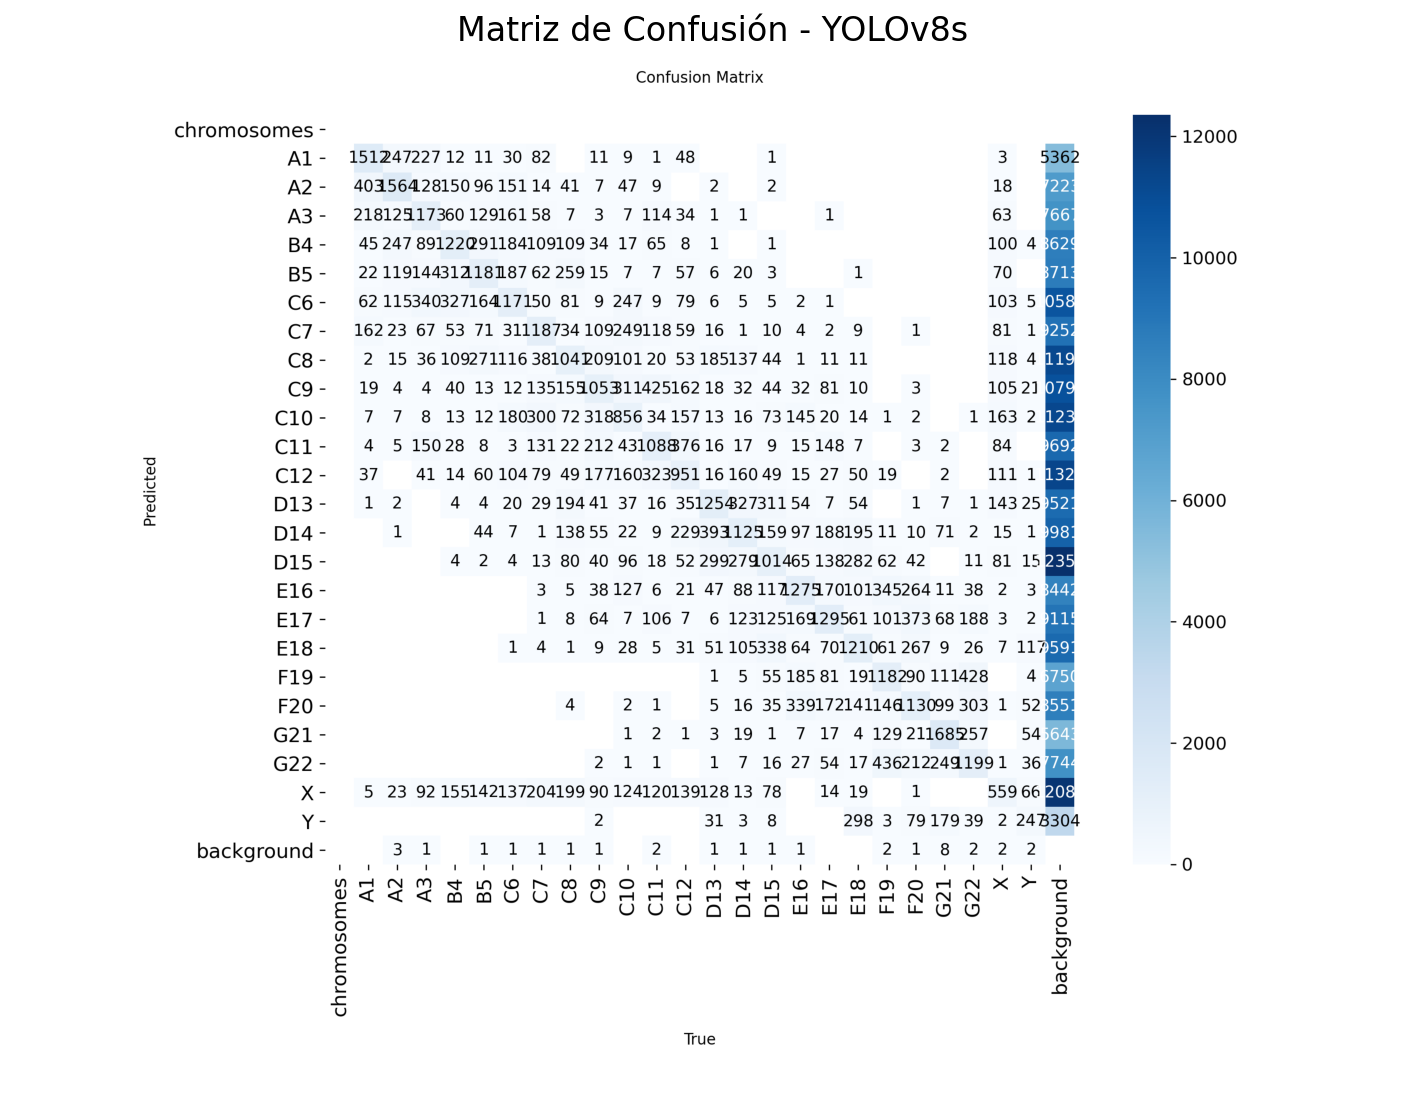

In [ ]:
# 2. Mostrar la Matriz de Confusión autogenerada durante el entrenamiento
confusion_matrix_path = Path('/content/runs/detect/chromosome_detection/yolov8s_run/confusion_matrix.png')

if confusion_matrix_path.exists():
    img_cm = cv2.imread(str(confusion_matrix_path))
    img_cm = cv2.cvtColor(img_cm, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 10), dpi=150)
    plt.imshow(img_cm)
    plt.axis('off')
    plt.title('Matriz de Confusión - YOLOv8s', fontsize=16)
    plt.show()
else:
    print("La matriz de confusión aún no se ha generado o se encuentra en otra ruta de entrenamiento.")